<a href="https://colab.research.google.com/github/mustafaalobaedy/tutorial-03/blob/main/Sentiment_Analysis_Instructor_Students.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🎓 Sentiment Analysis Tutorial — Complete VERSION  
## 🟠 Built for Google Colab · Fake vs Real News Dataset

### Complete Walkthrough: Data Acquisition → Preprocessing → EDA → Sentiment

---

### Learning Objectives
By the end of this tutorial, you will be able to:
1. **Acquire data** from Kaggle via the `kagglehub` API
2. **Clean and preprocess** raw text data for NLP
3. **Perform exploratory data analysis (EDA)** on text data
4. **Compute sentiment** using VADER and compare across two groups (Fake vs Real news)

### Dataset
**Fake and Real News Dataset** by Clément Bisaillon — https://www.kaggle.com/datasets/clmentbisaillon/fake-and-real-news-dataset
- `True.csv` — ~21,400 real news articles from Reuters
- `Fake.csv` — ~23,500 fake news articles from various outlets
- Columns: `title`, `text`, `subject`, `date`
- Time period: 2016–2017 (mostly U.S. politics)

### Why this dataset?
Unlike scraping APIs, this works offline-ish (fetches once), has **labeled groups** (Fake/Real) that make sentiment comparison meaningful, and gives a real NLP problem that appears in research. Fake news tends to be more emotionally charged — students can actually *see* this in the sentiment scores.

### Tutorial Duration: ~90 minutes

## 📘 TEACHING NOTES

**Colab gotchas:**
1. **Runtime disconnects erase files** — downloaded data has to be re-fetched. `kagglehub` caches it though, so within a session it's fast.
2. **Dataset is ~45,000 rows** — we'll sample 5,000 per class to keep EDA snappy. Demo the full data too if there's time.
3. **Most libraries pre-installed** — only `vaderSentiment`, `wordcloud`, `kagglehub` need installation.

# 📦 Section 0: Setup

In [29]:
# Install Colab-missing libraries (~30 seconds)
!pip install vaderSentiment wordcloud kagglehub -q
print('✅ Install complete')

✅ Install complete


In [30]:
# Imports
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re           # access the built-in regular expression (RegEx) module
import string
import os

# specialized dictionary subclass used for tallying hashable objects
from collections import Counter

#  Natural Language Toolkit (NLTK),
# a comprehensive library for building Python programs to work with human language data
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from wordcloud import WordCloud

# Download NLTK resources

#unsupervised trainable tokenizer that splits text into sentence
nltk.download('punkt', quiet=True)

# is the required data package for tokenization, replacing the older punkt resource
nltk.download('punkt_tab', quiet=True)

# Stopwords are common words (like "the", "is", "in") t
# hat are often filtered out during text preprocessing in
# Natural Language Processing (NLP)
# because they carry little semantic value for certain tasks.
nltk.download('stopwords', quiet=True)

# WordNet is a lexical database for the English language is part of the NLTK
nltk.download('wordnet', quiet=True)

%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

print('✅ All libraries loaded')

✅ All libraries loaded


# 📥 Section 1: Data Acquisition from Kaggle

## 1.1 Why `kagglehub`?

Historically, downloading from Kaggle required setting up API tokens, uploading `kaggle.json` files, etc. — tedious in a classroom setting.

`kagglehub` makes it a one-liner. For **public** datasets (like ours), you don't even need authentication.

**Teacher talking points:**
- Demo that `kagglehub.dataset_download()` returns a local path to the cached files
- Show students the data is now in `/root/.cache/kagglehub/...` on the Colab VM
- Mention: for private/competition datasets, you *would* need Kaggle API credentials — but for this public dataset we don't

In [31]:
# Download the dataset (first run: ~30 seconds, after: cached/instant)
path = kagglehub.dataset_download('clmentbisaillon/fake-and-real-news-dataset')
print(f'📂 Dataset downloaded to: {path}')
print(f'📄 Files in the folder: {os.listdir(path)}')

Using Colab cache for faster access to the 'fake-and-real-news-dataset' dataset.
📂 Dataset downloaded to: /kaggle/input/fake-and-real-news-dataset
📄 Files in the folder: ['True.csv', 'Fake.csv']


In [32]:
# Load both CSVs into DataFrames
fake_df = pd.read_csv(os.path.join(path, 'Fake.csv'))
true_df = pd.read_csv(os.path.join(path, 'True.csv'))

print(f'Fake news articles: {len(fake_df):,}')
print(f'Real news articles: {len(true_df):,}')
print(f'\nColumns: {list(fake_df.columns)}')
fake_df.head(3)

Fake news articles: 23,481
Real news articles: 21,417

Columns: ['title', 'text', 'subject', 'date']


,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"


## 1.2 Combine and Label

We'll merge both DataFrames into one, adding a `label` column that says whether each article is `Fake` or `Real`. This label is what makes the analysis interesting — we can compare sentiment between the two groups.

In [33]:
# Add a label column to each before merging
fake_df['label'] = 'Fake'
true_df['label'] = 'Real'

# Combine
df = pd.concat([fake_df, true_df], ignore_index=True)

# Shuffle so Fake and Real rows are interleaved (important before sampling)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

print(f'Combined shape: {df.shape}')
print(f"\nLabel distribution:\n{df['label'].value_counts()}")
df.head()

Combined shape: (44898, 5)

Label distribution:
label
Fake    23481
Real    21417
Name: count, dtype: int64


,title,text,subject,date,label
0,Ben Stein Calls Out 9th Circuit Court: Committ...,"21st Century Wire says Ben Stein, reputable pr...",US_News,"February 13, 2017",Fake
1,Trump drops Steve Bannon from National Securit...,WASHINGTON (Reuters) - U.S. President Donald T...,politicsNews,"April 5, 2017",Real
2,Puerto Rico expects U.S. to lift Jones Act shi...,(Reuters) - Puerto Rico Governor Ricardo Rosse...,politicsNews,"September 27, 2017",Real
3,OOPS: Trump Just Accidentally Confirmed He Le...,"On Monday, Donald Trump once again embarrassed...",News,"May 22, 2017",Fake
4,Donald Trump heads for Scotland to reopen a go...,"GLASGOW, Scotland (Reuters) - Most U.S. presid...",politicsNews,"June 24, 2016",Real


## 1.3 Sample for Classroom Speed

45,000 articles is a lot — cleaning + tokenizing would take several minutes. For the tutorial, we'll sample **2,500 from each class** (5,000 total). This keeps things snappy while preserving the Fake/Real balance.

**Teaching note:** Demonstrate that the full dataset runs fine if time permits — students should see that our pipeline scales.

In [34]:
# Stratified sample: 2,500 per class
SAMPLE_PER_CLASS = 2500

df = (
    df.groupby('label', group_keys=False) # group_keys=False prevents the label column from becoming the index after grouping.
      .apply(lambda g: g.sample(n=SAMPLE_PER_CLASS, random_state=42))
      .sample(frac=1, random_state=42)   # reshuffle frac=1 means it samples 100% of the data
      .reset_index(drop=True) #dropping the old index column.
)
print(f'Sampled dataset: {len(df):,} rows')
print(f"\nLabel distribution:\n{df['label'].value_counts()}")

Sampled dataset: 5,000 rows

Label distribution:
label
Fake    2500
Real    2500
Name: count, dtype: int64


/tmp/ipykernel_9535/1478422904.py:6: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: g.sample(n=SAMPLE_PER_CLASS, random_state=42))


# 🧹 Section 2: Preprocessing & Cleaning

## 2.1 Initial Inspection

Before cleaning, always look at your raw data.

In [35]:
print('Shape:', df.shape)
print('\nData types:')
print(df.dtypes)
print('\nMissing values per column:')
print(df.isnull().sum())
print(f'\nDuplicate rows: {df.duplicated().sum()}')
print(f'Duplicate titles: {df["title"].duplicated().sum()}')

Shape: (5000, 5)

Data types:
title      object
text       object
subject    object
date       object
label      object
dtype: object

Missing values per column:
title      0
text       0
subject    0
date       0
label      0
dtype: int64

Duplicate rows: 3
Duplicate titles: 66


In [36]:
# What subjects appear in each class?
print('SUBJECTS in Real news:')
print(df[df['label']=='Real']['subject'].value_counts())
print('\nSUBJECTS in Fake news:')
print(df[df['label']=='Fake']['subject'].value_counts())

SUBJECTS in Real news:
subject
politicsNews    1299
worldnews       1201
Name: count, dtype: int64

SUBJECTS in Fake news:
subject
News               970
politics           766
left-news          441
Government News    164
Middle-east         85
US_News             74
Name: count, dtype: int64


## 2.2 Handle Duplicates & Empty Rows

**Teaching note:** The real news (Reuters) tends to be well-formed; fake news has more quirks like empty titles, duplicate articles, and unusual formatting.

In [37]:
# Drop duplicates and empty rows
df = df.drop_duplicates(subset='title').reset_index(drop=True)
print(f'✅ After deduplication: {len(df):,} rows')

✅ After deduplication: 4,934 rows


In [38]:
# Combine title + text into the 'full_text' column we'll analyze
df['full_text'] = df['title'].fillna('') + '. ' + df['text'].fillna('')
df['full_text'] = df['full_text'].str.strip() # to clean white space
df = df[df['full_text'].str.len() > 20].reset_index(drop=True)


print(f"\nLabel distribution (should still be ~balanced):\n{df['label'].value_counts()}")


Label distribution (should still be ~balanced):
label
Real    2495
Fake    2439
Name: count, dtype: int64


In [39]:
df.head(3)

,title,text,subject,date,label,full_text
0,#BlackLivesMatterTerrorists Shut Down Kids Vis...,These poor kids have probably practiced for mo...,left-news,"Dec 23, 2015",Fake,#BlackLivesMatterTerrorists Shut Down Kids Vis...
1,China starts formal legal proceedings against ...,BEIJING (Reuters) - China s prosecutor began o...,worldnews,"December 11, 2017",Real,China starts formal legal proceedings against ...
2,Irish government says significant progress on ...,DUBLIN (Reuters) - Ireland has made significa...,worldnews,"December 4, 2017",Real,Irish government says significant progress on ...


## 2.3 Why Preprocessing Matters

Raw news text is messy. Before analysis we need to clean it.

| Step | What it does | Why |
|---|---|---|
| Lowercase | `Trump` → `trump` | Same word regardless of case |
| Remove URLs | `http://...` → `` | URLs don't carry sentiment |
| Remove HTML/entities | `&amp;` → `` | Scraping artifacts |
| Remove `(Reuters)` tags | Real news headers | Would be a dead giveaway for the model |
| Remove punctuation | `great!!!` → `great` | Reduces noise |
| Remove numbers | `2017` → `` | Usually not sentiment-bearing |
| Tokenize | `"I love it"` → `[I, love, it]` | Split into words |
| Remove stopwords | Drop `the`, `is`, `and` | Low-information words |
| Lemmatize | `running` → `run` | Collapse word variants |

**⚠️ IMPORTANT:** For **VADER sentiment analysis**, we use the *original* text — VADER uses capitalization and punctuation (`GREAT!!!` > `great`). Cleaned text is only for **EDA** (word counts, word clouds).

## 2.4 Build the Cleaning Function

 Build this step-by-step. Show one regex at a time, print before/after.

In [40]:
def clean_text(text):
    """Heavy cleaning for EDA / word-cloud purposes."""
    if not isinstance(text, str):
        return ''
    text = text.lower()
    text = re.sub(r'http\S+|www\.\S+', '', text)              # Removes URLs
    text = re.sub(r'&[a-z#0-9]+;', ' ', text)                  # Removes HTML entities
    text = re.sub(r'\(reuters\)', '', text)                     # Removes Reuters tag (would leak label)
    text = re.sub(r'@\w+', '', text)                           #  Removes mentions (twitter-style)
    text = re.sub(r'#\w+', '', text)                           # Removes #hashtags
    text = re.sub(r'\d+', '', text)                            # Removes numbers
    text = text.translate(str.maketrans('', '', string.punctuation))  # Removes punctuation
    text = re.sub(r'\s+', ' ', text).strip()                   # Removes whitespace
    return text


In [41]:
# Quick test to clean_text
sample = 'WASHINGTON (Reuters) - President Trump said on Monday the deal was "GREAT!!!" and visited https://example.com on 2017-05-03.'
print('BEFORE:', sample)
print('AFTER: ', clean_text(sample))


BEFORE: WASHINGTON (Reuters) - President Trump said on Monday the deal was "GREAT!!!" and visited https://example.com on 2017-05-03.
AFTER:  washington president trump said on monday the deal was great and visited on


## 2.5 Tokenize, Remove Stopwords, Lemmatize

In [42]:
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# News-specific stopwords (filler words that dominate without adding meaning)
extra_stopwords = {'said', 'would', 'could', 'also', 'one', 'two', 'new',
                   'year', 'years', 'day', 'time', 'people', 'us', 'mr', 'mrs'}
stop_words = stop_words.union(extra_stopwords)

def tokenize_and_lemmatize(text):
    """Tokenize → drop stopwords & short words → lemmatize."""
    tokens = word_tokenize(text)
    # This is a list comprehension that filters the tokens.
    # It keeps only tokens that are purely alphabetic
     # (removing punctuation and numbers), are not in the stop_words set,
     # and are longer than 2 characters (to remove very short, often uninformative words).
    tokens = [t for t in tokens if t.isalpha() and t not in stop_words and len(t) > 2]
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return tokens

sample_clean = clean_text(sample)
print('Cleaned:  ', sample_clean)
print('Tokenized:', tokenize_and_lemmatize(sample_clean))

Cleaned:   washington president trump said on monday the deal was great and visited on
Tokenized: ['washington', 'president', 'trump', 'monday', 'deal', 'great', 'visited']


## 2.6 Apply the Pipeline to the Whole Dataset

⏱️ This will take ~1 minute for 5,000 articles.

In [43]:
print('Cleaning 5,000 articles — this will take about 1 minute...')
df['text_clean'] = df['full_text'].apply(clean_text)
df['tokens'] = df['text_clean'].apply(tokenize_and_lemmatize)
df['clean_joined'] = df['tokens'].apply(lambda tokens: ' '.join(tokens))

df['char_count'] = df['full_text'].str.len()
df['word_count'] = df['full_text'].str.split().str.len()
df['token_count'] = df['tokens'].str.len()

# Drop rows that became empty after cleaning
df = df[df['token_count'] > 0].reset_index(drop=True)

print(f'✅ Final cleaned dataset: {len(df):,} rows')
df[['label', 'full_text', 'clean_joined', 'word_count', 'token_count']].head(3)

Cleaning 5,000 articles — this will take about 1 minute...
✅ Final cleaned dataset: 4,932 rows


,label,full_text,clean_joined,word_count,token_count
0,Fake,#BlackLivesMatterTerrorists Shut Down Kids Vis...,shut kid visit santa shut major airport poor k...,261,126
1,Real,China starts formal legal proceedings against ...,china start formal legal proceeding disgraced ...,297,150
2,Real,Irish government says significant progress on ...,irish government say significant progress brex...,114,60


Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


In [44]:
df.head(1)

,title,text,subject,date,label,full_text,text_clean,tokens,clean_joined,char_count,word_count,token_count
0,#BlackLivesMatterTerrorists Shut Down Kids Vis...,These poor kids have probably practiced for mo...,left-news,"Dec 23, 2015",Fake,#BlackLivesMatterTerrorists Shut Down Kids Vis...,shut down kids visits with santa at mall…attem...,"[shut, kid, visit, santa, shut, major, airport...",shut kid visit santa shut major airport poor k...,1909,261,126


# 📊 Section 3: Exploratory Data Analysis (EDA)

Now the fun part. We'll answer:
1. How long are the articles? Does length differ between Fake and Real?
2. What are the most common words in each class?
3. **The big question: Is Fake news more emotionally charged than Real news?**
4. Which articles are most extreme in sentiment?

## 3.1 Descriptive Statistics by Class

In [45]:
df.groupby('label')[['char_count', 'word_count', 'token_count']].describe().round(1)

char_count                                                          \
           count    mean     std    min     25%     50%     75%      max   
label                                                                      
Fake      2437.0  2633.7  2296.8   50.0  1544.0  2254.0  3135.0  27554.0   
Real      2495.0  2479.9  1748.6  204.0  1015.0  2330.0  3296.5  29849.0   

      word_count         ...                token_count                      \
           count   mean  ...    75%     max       count   mean    std   min   
label                    ...                                                  
Fake      2437.0  437.3  ...  521.0  4561.0      2437.0  227.0  195.6   5.0   
Real      2495.0  400.6  ...  534.0  5181.0      2495.0  220.1  152.0  19.0   

                                    
         25%    50%    75%     max  
label                               
Fake   136.0  195.0  268.0  2337.0  
Real    89.0  208.0  292.0  2264.0  

[2 rows x 24 columns]

## 3.2 Text Length Distribution by Class

Plot a histogram of word count, split by label. Look for differences.

/tmp/ipykernel_9535/2209810682.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='label', y='word_count', data=df, ax=axes[1],


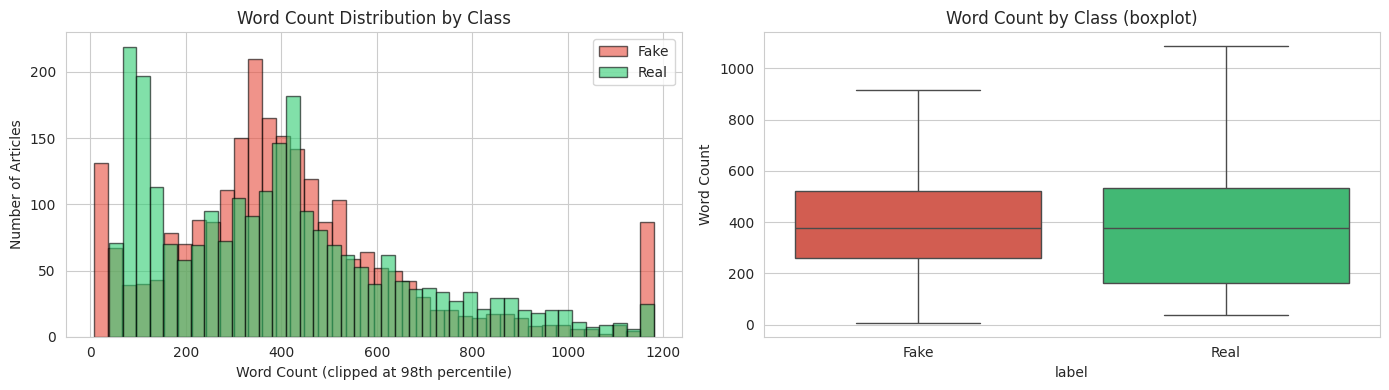

In [46]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Clip outliers for readability (the tail is very long)
clip = df['word_count'].quantile(0.98)

for label, color in [('Fake', '#e74c3c'), ('Real', '#2ecc71')]:
    axes[0].hist(df[df['label']==label]['word_count'].clip(upper=clip),
                 bins=40, alpha=0.6, label=label, color=color, edgecolor='black')
axes[0].set_title('Word Count Distribution by Class')
axes[0].set_xlabel('Word Count (clipped at 98th percentile)')
axes[0].set_ylabel('Number of Articles')
axes[0].legend()

# Boxplot for a cleaner side-by-side view
sns.boxplot(x='label', y='word_count', data=df, ax=axes[1],
            palette={'Fake':'#e74c3c', 'Real':'#2ecc71'}, showfliers=False)
axes[1].set_title('Word Count by Class (boxplot)')
axes[1].set_ylabel('Word Count')

plt.tight_layout()
plt.show()

## 3.3 Most Common Subjects

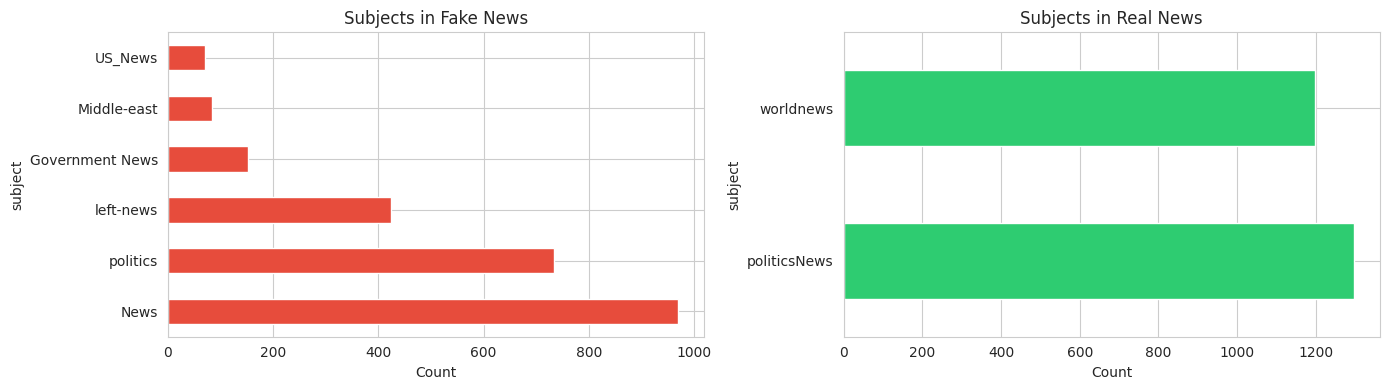

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df[df['label']=='Fake']['subject'].value_counts().plot(
    kind='barh', ax=axes[0], color='#e74c3c')
axes[0].set_title('Subjects in Fake News')
axes[0].set_xlabel('Count')

df[df['label']=='Real']['subject'].value_counts().plot(
    kind='barh', ax=axes[1], color='#2ecc71')
axes[1].set_title('Subjects in Real News')
axes[1].set_xlabel('Count')

plt.tight_layout()
plt.show()

## 3.4 Top Words by Class

After cleaning, which words dominate each class?

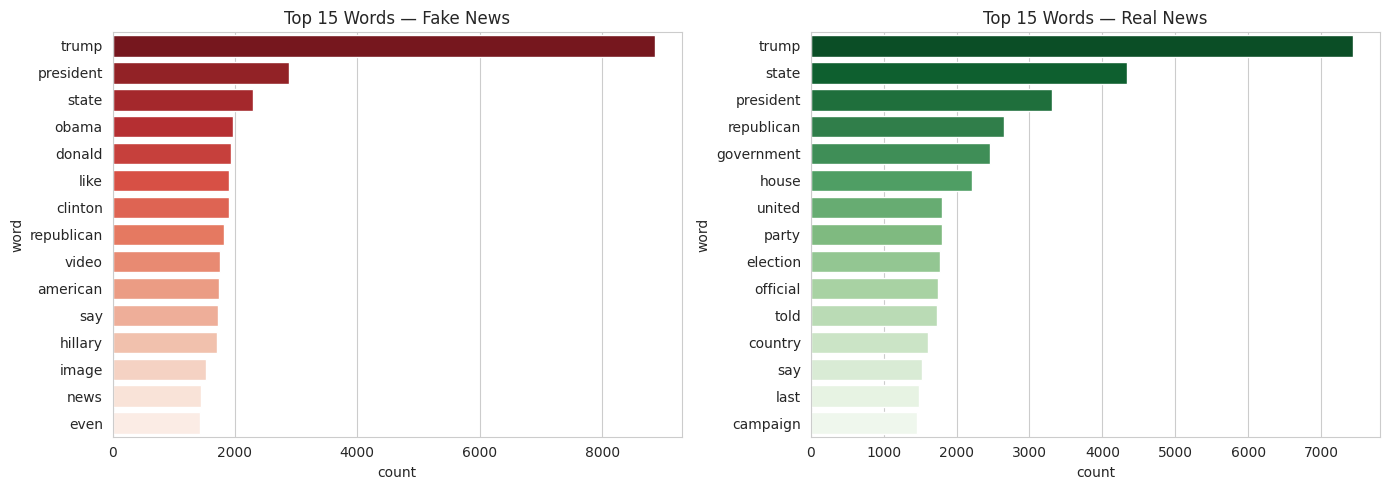

In [48]:
def top_words_for(label, n=15):
    tokens = [t for toks in df[df['label']==label]['tokens'] for t in toks]
    return pd.DataFrame(Counter(tokens).most_common(n), columns=['word', 'count'])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fake_top = top_words_for('Fake', 15)
sns.barplot(
    x='count',
    y='word',
    hue='word',
    data=fake_top,
    ax=axes[0],
    palette='Reds_r',
    legend=False
)
axes[0].set_title('Top 15 Words — Fake News')

real_top = top_words_for('Real', 15)
sns.barplot(
    x='count',
    y='word',
    hue='word',
    data=real_top,
    ax=axes[1],
    palette='Greens_r',
    legend=False
)
axes[1].set_title('Top 15 Words — Real News')

plt.tight_layout()
plt.show()

## 3.5 Word Clouds by Class

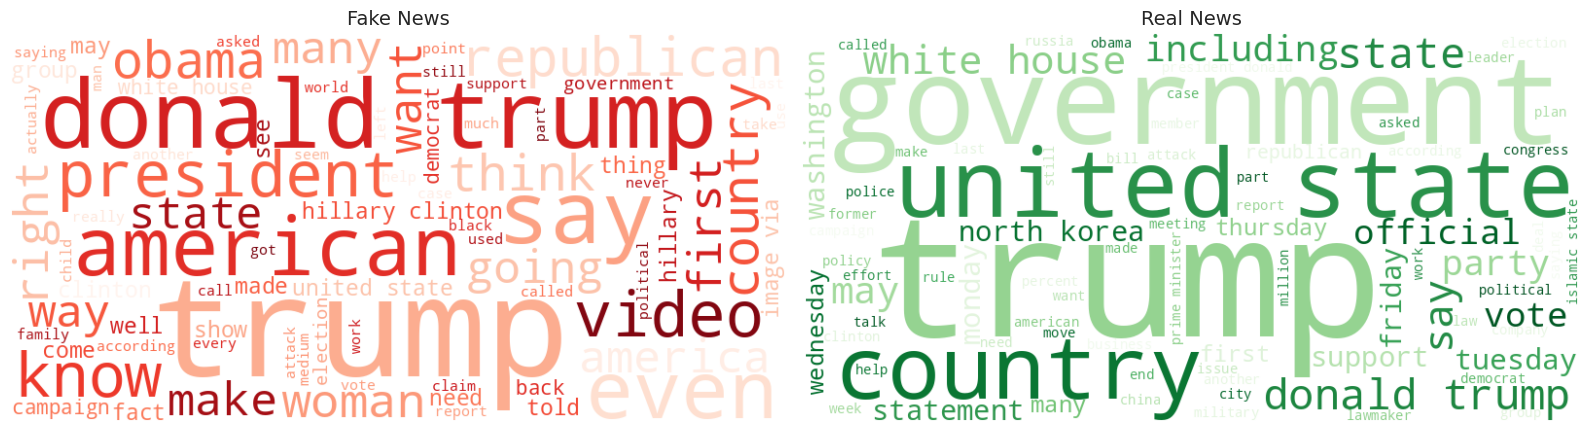

In [49]:
fake_text = ' '.join(df[df['label']=='Fake']['clean_joined'])
real_text = ' '.join(df[df['label']=='Real']['clean_joined'])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

wc_fake = WordCloud(width=800, height=400, background_color='white',
                    colormap='Reds', max_words=80).generate(fake_text)
axes[0].imshow(wc_fake, interpolation='bilinear')
axes[0].set_title('Fake News', fontsize=14)
axes[0].axis('off')

wc_real = WordCloud(width=800, height=400, background_color='white',
                    colormap='Greens', max_words=80).generate(real_text)
axes[1].imshow(wc_real, interpolation='bilinear')
axes[1].set_title('Real News', fontsize=14)
axes[1].axis('off')

plt.tight_layout()
plt.show()

## 3.6 Publication Timeline

When was each class of news published? The Kaggle dataset covers mostly 2016–2017.

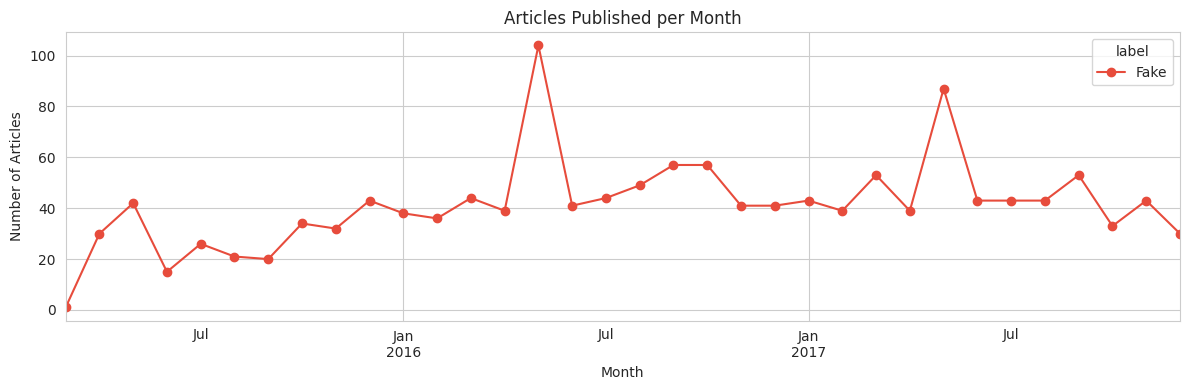

In [50]:
# Parse the date column. Dates come in mixed formats, so errors='coerce' is safer.
df['date_parsed'] = pd.to_datetime(df['date'], errors='coerce')
df_dated = df.dropna(subset=['date_parsed']).copy()
df_dated['month'] = df_dated['date_parsed'].dt.to_period('M')

monthly = df_dated.groupby(['month', 'label']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(12, 4))
monthly.plot(ax=ax, color={'Fake':'#e74c3c', 'Real':'#2ecc71'}, marker='o')
ax.set_title('Articles Published per Month')
ax.set_ylabel('Number of Articles')
ax.set_xlabel('Month')
plt.tight_layout()
plt.show()

## 3.7 Sentiment Analysis with VADER

**VADER** (Valence Aware Dictionary and sEntiment Reasoner) returns a **compound** score from −1 (most negative) to +1 (most positive).

### ⚠️ Use ORIGINAL text with VADER, not the cleaned version!
VADER uses capitalization (`GREAT` > `great`) and punctuation (`good!!!` > `good`) as sentiment signals.

In [51]:
analyzer = SentimentIntensityAnalyzer()

def get_sentiment(text):
    """Return the VADER compound sentiment score (-1 to +1)."""
    if not isinstance(text, str) or not text.strip():
        return 0.0
    return analyzer.polarity_scores(text)['compound']

print('Scoring 5,000 articles — this will take ~30 seconds...')
df['sentiment_score'] = df['full_text'].apply(get_sentiment)

def categorize(score):
    if score >= 0.05:   return 'Positive'
    elif score <= -0.05: return 'Negative'
    else:                return 'Neutral'

df['sentiment'] = df['sentiment_score'].apply(categorize)
df[['label', 'title', 'sentiment_score', 'sentiment']].head(10)

Scoring 5,000 articles — this will take ~30 seconds...


,label,title,sentiment_score,sentiment
0,Fake,#BlackLivesMatterTerrorists Shut Down Kids Vis...,-0.9814,Negative
1,Real,China starts formal legal proceedings against ...,-0.8840,Negative
2,Real,Irish government says significant progress on ...,0.9652,Positive
3,Fake,WHOA! THIS DC DIVA Blows Off Traffic Laws In A...,0.8626,Positive
4,Fake,WATCH: CBS “This Morning” HACK HOSTS BEG BERNI...,-0.9092,Negative
5,Fake,Despicable Trump Suggests Female Senator Woul...,-0.9479,Negative
6,Fake,Tim Allen Cracks A Joke About Obama – Would B...,-0.3411,Negative
7,Fake,FOX NEWS REPORTER ASKS MAYOR Why She’s Using T...,0.9921,Positive
8,Fake,"STUDENTS AT MAJOR UNIVERSITY: Black Students, ...",0.3925,Positive
9,Fake,CNN CALLS IT: A Democrat Will Represent Alaba...,-0.5106,Negative


## 3.8 🎯 The Big Question: Is Fake News More Emotional Than Real News?

This is the headline insight. Compare the distribution of sentiment scores for the two classes.

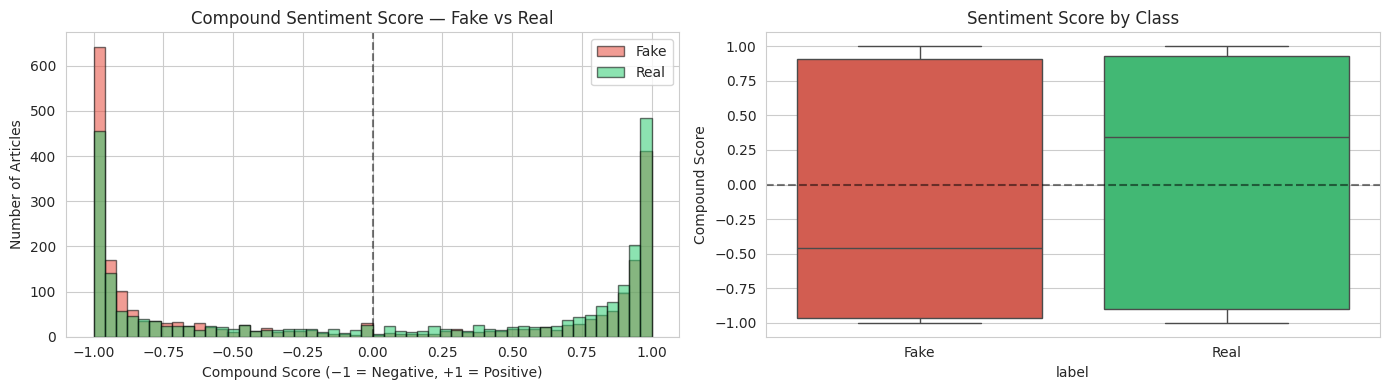

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Overlapping histograms of the raw compound score
for label, color in [('Fake', '#e74c3c'), ('Real', '#2ecc71')]:
    axes[0].hist(df[df['label']==label]['sentiment_score'],
                 bins=50, alpha=0.55, label=label, color=color, edgecolor='black')
axes[0].axvline(0, color='black', linestyle='--', alpha=0.5)
axes[0].set_title('Compound Sentiment Score — Fake vs Real')
axes[0].set_xlabel('Compound Score (−1 = Negative, +1 = Positive)')
axes[0].set_ylabel('Number of Articles')
axes[0].legend()

# Boxplot — sharpens the comparison
sns.boxplot(x='label', y='sentiment_score', data=df, ax=axes[1],
            hue='label', palette={'Fake':'#e74c3c', 'Real':'#2ecc71'}, showfliers=False)
axes[1].axhline(0, color='black', linestyle='--', alpha=0.5)
axes[1].set_title('Sentiment Score by Class')
axes[1].set_ylabel('Compound Score')

plt.tight_layout()
plt.show()

In [53]:
# Statistics behind the picture
summary = df.groupby('label')['sentiment_score'].agg(
    ['mean', 'std', 'median', 'min', 'max']
).round(3)
print('📊 Sentiment score summary by class:\n')
print(summary)

# Which class has higher EMOTIONAL INTENSITY (absolute value of score)?
df['sentiment_intensity'] = df['sentiment_score'].abs()
print('\n📊 EMOTIONAL INTENSITY (|score|) by class:')
print(df.groupby('label')['sentiment_intensity'].agg(['mean', 'median']).round(3))

print('\n💡 Interpretation: If Fake news has higher |score| on average,')
print('   it means fake news is more emotionally charged, regardless of direction.')

📊 Sentiment score summary by class:

        mean    std  median  min  max
label                                
Fake  -0.102  0.859  -0.462 -1.0  1.0
Real   0.093  0.830   0.347 -1.0  1.0

📊 EMOTIONAL INTENSITY (|score|) by class:
        mean  median
label               
Fake   0.832   0.945
Real   0.792   0.925

💡 Interpretation: If Fake news has higher |score| on average,
   it means fake news is more emotionally charged, regardless of direction.


## 3.9 Sentiment Category Breakdown

What proportion of each class is Positive/Neutral/Negative?

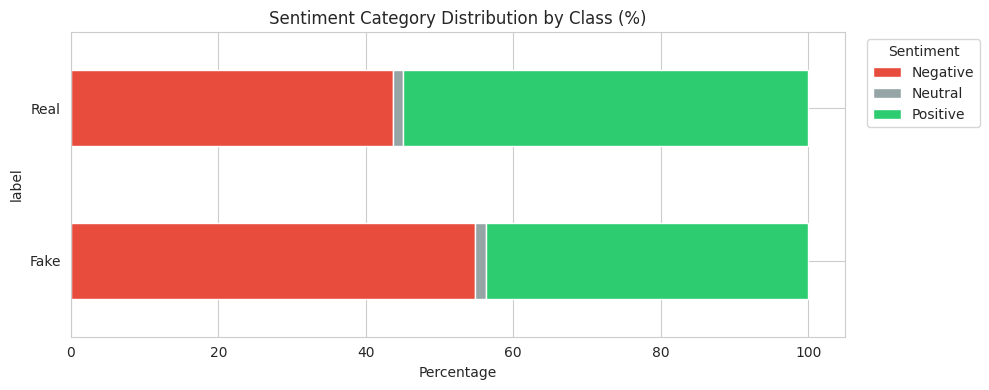


📊 Breakdown (rows sum to 100%):
sentiment  Negative  Neutral  Positive
label                                 
Fake           54.8      1.5      43.7
Real           43.7      1.4      54.9


In [54]:
sentiment_by_label = pd.crosstab(df['label'], df['sentiment'], normalize='index') * 100

fig, ax = plt.subplots(figsize=(10, 4))
sentiment_by_label[['Negative', 'Neutral', 'Positive']].plot(
    kind='barh', stacked=True, ax=ax,
    color=['#e74c3c', '#95a5a6', '#2ecc71'])
ax.set_title('Sentiment Category Distribution by Class (%)')
ax.set_xlabel('Percentage')
ax.legend(title='Sentiment', bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

print('\n📊 Breakdown (rows sum to 100%):')
print(sentiment_by_label.round(1))

## 3.10 Top Positive & Negative Articles

Sanity check: do the extreme scores match our intuition?

In [55]:
print('🔝 TOP 5 MOST POSITIVE ARTICLES:')
print('-' * 70)
for _, row in df.nlargest(5, 'sentiment_score').iterrows():
    print(f"  [{row['sentiment_score']:+.3f} | {row['label']:4s}] {row['title'][:80]}")

print('\n🔻 TOP 5 MOST NEGATIVE ARTICLES:')
print('-' * 70)
for _, row in df.nsmallest(5, 'sentiment_score').iterrows():
    print(f"  [{row['sentiment_score']:+.3f} | {row['label']:4s}] {row['title'][:80]}")

🔝 TOP 5 MOST POSITIVE ARTICLES:
----------------------------------------------------------------------
  [+1.000 | Fake] ‘One for the Ages’ Full Video and Transcript of Trump’s Incredible UN Speech [Vi
  [+1.000 | Real] Transcript of Reuters interview with EPA Administrator Scott Pruitt
  [+1.000 | Fake] COLLEGES MAY BE FORCED To Stop Pushing Qualified White Students To Back Of Line.
  [+1.000 | Fake] DELEGATES FOR DUMMIES: How They’re Awarded…And How Many Your Candidate Needs To 
  [+1.000 | Fake] HOW LEFT- LEANING GOOGLE’S SECRET DECISIONS COULD CHOOSE OUR NEXT PRESIDENT

🔻 TOP 5 MOST NEGATIVE ARTICLES:
----------------------------------------------------------------------
  [-1.000 | Fake] NOTHING NEW: ‘Fake’ & Weaponized News Has Long Haunted Our War-Weary World
  [-1.000 | Fake] AFGHANISTAN: Forgotten, But Not Gone
  [-1.000 | Real] Tension grips Nigerian city as separatist leader goes missing
  [-1.000 | Fake] UPDATED VIDEO: IS THIS AMERICA? CONSERVATIVES And Their Families Exper

## 3.11 💾 Save & Download the Final Dataset

⚠️ **Colab's `/content` folder is temporary.** We must explicitly download the CSV.

In [56]:
final_cols = ['title', 'label', 'subject', 'date', 'full_text', 'clean_joined',
              'word_count', 'token_count', 'sentiment_score', 'sentiment']
df[final_cols].to_csv('news_sentiment_analyzed.csv', index=False)
print(f'✅ Saved {len(df):,} rows to news_sentiment_analyzed.csv')

# Download to your computer
from google.colab import files
files.download('news_sentiment_analyzed.csv')

✅ Saved 4,932 rows to news_sentiment_analyzed.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

---

# 🎯 Summary & Key Takeaways

## What we found:

1. **Fake and real news differ in length** — real (Reuters) articles are more uniform; fake varies more
2. **Top words reveal topic differences** — real news dominated by Reuters reporting style; fake news uses more charged vocabulary
3. **⭐ The key finding: Fake news is more emotionally charged** — it has higher average |sentiment score| than real news, skewing more negative overall
4. **This is a research-quality finding** — matches published literature on fake news detection

## What students learned:

1. **Data acquisition** — Using `kagglehub` to download datasets without API token faff
2. **Preprocessing** — The full NLP cleaning pipeline, including dataset-specific fixes like the `(Reuters)` tag leak
3. **Comparative EDA** — Plotting distributions *split by group* instead of single-group analysis
4. **Sentiment Analysis** — VADER scoring + interpretation + group comparison
5. **Critical thinking** — Why fake news might be more emotional (engagement bait)

## Extensions:

- Build a classifier using the sentiment features to predict Fake vs Real
- Compare VADER with a transformer model (`distilbert-base-uncased-finetuned-sst-2-english`)
- N-gram analysis — which bigrams are most fake-predictive?
- Topic modeling (LDA) combined with sentiment
